In [0]:
from nltk.corpus import sentiwordnet as swn
from nltk import download

# resursele necesare
download('sentiwordnet')
download('wordnet')

# cuvant analizat
word = 'good'

# 'a' = adjective
synsets = list(swn.senti_synsets(word, 'a'))

print(f"Toate sensurile posibile pentru cuvântul '{word}' ca adjectiv:\n")

# Parcurgem fiecare sens și afișăm scorurile asociate
for i, s in enumerate(synsets):
    print(f"{i+1}. Nume synset: {s.synset.name()}")
    print(f"   Definiție: {s.synset.definition()}")
    print(f"   Scor pozitiv: {s.pos_score():.2f}")
    print(f"   Scor negativ: {s.neg_score():.2f}")
    print(f"   Scor obiectiv: {s.obj_score():.2f}")
    print("=" * 10)

Toate sensurile posibile pentru cuvântul 'good' ca adjectiv:

1. Nume synset: good.a.01
   Definiție: having desirable or positive qualities especially those suitable for a thing specified
   Scor pozitiv: 0.75
   Scor negativ: 0.00
   Scor obiectiv: 0.25
2. Nume synset: full.s.06
   Definiție: having the normally expected amount
   Scor pozitiv: 0.00
   Scor negativ: 0.00
   Scor obiectiv: 1.00
3. Nume synset: good.a.03
   Definiție: morally admirable
   Scor pozitiv: 1.00
   Scor negativ: 0.00
   Scor obiectiv: 0.00
4. Nume synset: estimable.s.02
   Definiție: deserving of esteem and respect
   Scor pozitiv: 1.00
   Scor negativ: 0.00
   Scor obiectiv: 0.00
5. Nume synset: beneficial.s.01
   Definiție: promoting or enhancing well-being
   Scor pozitiv: 0.62
   Scor negativ: 0.00
   Scor obiectiv: 0.38
6. Nume synset: good.s.06
   Definiție: agreeable or pleasing
   Scor pozitiv: 1.00
   Scor negativ: 0.00
   Scor obiectiv: 0.00
7. Nume synset: good.s.07
   Definiție: of moral excelle

[nltk_data] Downloading package sentiwordnet to /root/nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [0]:
from nltk.corpus import sentiwordnet as swn
from nltk.corpus import wordnet as wn
from nltk import pos_tag, word_tokenize, download

# resursele necesare 
download('sentiwordnet')
download('wordnet')
download('punkt')
download('averaged_perceptron_tagger')

text = """Abordarea bazată pe norme reprezintă o metodă practică de analiză a textului,
care nu necesită procesul de instruire al unui model și nu implică utilizarea
algoritmilor de învățare automată. În cadrul acestei metode, analiza se
realizează prin aplicarea unui set de reguli predefinite, în funcție de care
fragmentele de text sunt clasificate în categorii de sentiment — pozitiv,
negativ sau neutru."""


#  conversie a etichetelor NLTK în format WordNet

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wn.ADJ
    elif treebank_tag.startswith('V'):
        return wn.VERB
    elif treebank_tag.startswith('N'):
        return wn.NOUN
    elif treebank_tag.startswith('R'):
        return wn.ADV
    else:
        return None

# tokenizare + etichetare 
tokens = word_tokenize(text)
tagged = pos_tag(tokens)

# calculăm scorurile medii
pos_total = neg_total = 0
count = 0

for word, tag in tagged:
    wn_tag = get_wordnet_pos(tag)
    if not wn_tag:
        continue
    synsets = list(swn.senti_synsets(word, wn_tag))
    if not synsets:
        continue
    s = synsets[0]  # luăm primul sens
    pos_total += s.pos_score()
    neg_total += s.neg_score()
    count += 1

if count > 0:
    pos_avg = pos_total / count
    neg_avg = neg_total / count
    print(f"Scor pozitiv mediu: {pos_avg:.3f}")
    print(f"Scor negativ mediu: {neg_avg:.3f}")
    print(f"Scor global: {pos_avg - neg_avg:.3f}")
else:
    print("niciun cuvânt din text nu a fost găsit în SentiWordNet.")

Scor pozitiv mediu: 0.028
Scor negativ mediu: 0.028
Scor global: 0.000


[nltk_data] Downloading package sentiwordnet to /root/nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


# afișarea cuvintelor găsite în SentiWordNet

In [0]:
from nltk.corpus import sentiwordnet as swn
from nltk.corpus import wordnet as wn
from nltk import pos_tag, word_tokenize, download

# Descărcăm resursele necesare (doar prima dată)
download('sentiwordnet')
download('wordnet')
download('punkt')
download('averaged_perceptron_tagger')

# Textul tău (poți schimba după dorință)
text = """Abordarea bazată pe norme reprezintă o metodă practică de analiză a textului,
care nu necesită procesul de instruire al unui model și nu implică utilizarea
algoritmilor de învățare automată. În cadrul acestei metode, analiza se
realizează prin aplicarea unui set de reguli predefinite, în funcție de care
fragmentele de text sunt clasificate în categorii de sentiment — pozitiv,
negativ sau neutru."""


#  convertire etichete POS (part of speech)

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wn.ADJ
    elif treebank_tag.startswith('V'):
        return wn.VERB
    elif treebank_tag.startswith('N'):
        return wn.NOUN
    elif treebank_tag.startswith('R'):
        return wn.ADV
    else:
        return None


# Tokenizare + etichetare

tokens = word_tokenize(text)
tagged = pos_tag(tokens)

# Căutăm cuvintele care există în SentiWordNet

found_words = []
for word, tag in tagged:
    wn_tag = get_wordnet_pos(tag)
    if not wn_tag:
        continue
    synsets = list(swn.senti_synsets(word, wn_tag))
    if synsets:
        s = synsets[0]  # primul sens
        found_words.append({
            'word': word,
            'synset': s.synset.name(),
            'pos_score': s.pos_score(),
            'neg_score': s.neg_score(),
            'obj_score': s.obj_score(),
        })


# Afișăm rezultatele

if found_words:
    print("Cuvinte găsite în SentiWordNet:\n")
    for item in found_words:
        print(f"Cuvânt: {item['word']}")
        print(f" - Synset: {item['synset']}")
        print(f" - Scor pozitiv: {item['pos_score']:.2f}")
        print(f" - Scor negativ: {item['neg_score']:.2f}")
        print(f" - Scor obiectiv: {item['obj_score']:.2f}")
        print("-" * 60)
else:
    print("niciun cuvânt din text nu a fost găsit în SentiWordNet.")


[nltk_data] Downloading package sentiwordnet to /root/nltk_data...

Cuvinte găsite în SentiWordNet:

Cuvânt: pe
 - Synset: pe.n.01
 - Scor pozitiv: 0.00
 - Scor negativ: 0.00
 - Scor obiectiv: 1.00
------------------------------------------------------------
Cuvânt: o
 - Synset: oxygen.n.01
 - Scor pozitiv: 0.00
 - Scor negativ: 0.00
 - Scor obiectiv: 1.00
------------------------------------------------------------
Cuvânt: care
 - Synset: care.n.01
 - Scor pozitiv: 0.00
 - Scor negativ: 0.00
 - Scor obiectiv: 1.00
------------------------------------------------------------
Cuvânt: al
 - Synset: aluminum.n.01
 - Scor pozitiv: 0.00
 - Scor negativ: 0.00
 - Scor obiectiv: 1.00
------------------------------------------------------------
Cuvânt: model
 - Synset: model.n.01
 - Scor pozitiv: 0.00
 - Scor negativ: 0.00
 - Scor obiectiv: 1.00
------------------------------------------------------------
Cuvânt: se
 - Synset: selenium.n.01
 - Scor pozitiv: 0.00
 - Scor negativ: 0.00
 - Scor obiectiv: 1.00
-------------------------------------------------------


[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [0]:
from nltk.corpus import sentiwordnet as swn
from nltk.corpus import wordnet as wn
from nltk import pos_tag, word_tokenize, download

# resursele necesare 
download('sentiwordnet')
download('wordnet')
download('punkt')
download('averaged_perceptron_tagger')

text = """Sentiment analysis, or opinion mining, is the process of analyzing large volumes of text to determine whether it expresses a positive sentiment, a negative sentiment or a neutral sentiment.
Companies now have access to more data about their customers than ever before, presenting both an opportunity and a challenge: analyzing the vast amounts of textual data available and extracting meaningful insights to guide their business decisions.
From emails and tweets to online survey responses, chats with customer service representatives and reviews, the sources available to gauge customer sentiment are seemingly endless. Sentiment analysis systems help companies better understand their customers, deliver stronger customer experiences and improve their brand reputation.
"""

#  conversie a etichetelor NLTK în format WordNet

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wn.ADJ
    elif treebank_tag.startswith('V'):
        return wn.VERB
    elif treebank_tag.startswith('N'):
        return wn.NOUN
    elif treebank_tag.startswith('R'):
        return wn.ADV
    else:
        return None

# tokenizare + etichetare 
tokens = word_tokenize(text)
tagged = pos_tag(tokens)

# calculăm scorurile medii
pos_total = neg_total = 0
count = 0

for word, tag in tagged:
    wn_tag = get_wordnet_pos(tag)
    if not wn_tag:
        continue
    synsets = list(swn.senti_synsets(word, wn_tag))
    if not synsets:
        continue
    s = synsets[0]  # luăm primul sens
    pos_total += s.pos_score()
    neg_total += s.neg_score()
    count += 1

if count > 0:
    pos_avg = pos_total / count
    neg_avg = neg_total / count
    print(f"Scor pozitiv mediu: {pos_avg:.3f}")
    print(f"Scor negativ mediu: {neg_avg:.3f}")
    print(f"Scor global: {pos_avg - neg_avg:.3f}")
else:
    print("niciun cuvânt din text nu a fost găsit în SentiWordNet.")

[nltk_data] Downloading package sentiwordnet to /root/nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Scor pozitiv mediu: 0.116
Scor negativ mediu: 0.058
Scor global: 0.058


In [0]:
%pip install textblob

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# textblob_sentiment.py
from textblob import TextBlob
text = """Sentiment analysis, or opinion mining, is the process of analyzing large volumes of text to determine whether it expresses a positive sentiment, a negative sentiment or a neutral sentiment.
Companies now have access to more data about their customers than ever before, presenting both an opportunity and a challenge: analyzing the vast amounts of textual data available and extracting meaningful insights to guide their business decisions.
From emails and tweets to online survey responses, chats with customer service representatives and reviews, the sources available to gauge customer sentiment are seemingly endless. Sentiment analysis systems help companies better understand their customers, deliver stronger customer experiences and improve their brand reputation.
"""
blob = TextBlob(text)
print("=== TextBlob (sentence-level) ===")
for i, s in enumerate(blob.sentences, 1):
    print(f"[Sent {i}] polarity={s.sentiment.polarity:.3f}  subjectivity={s.sentiment.subjectivity:.3f}")
print("\n=== TextBlob (overall) ===")
print(f"polarity={blob.sentiment.polarity:.3f}  subjectivity={blob.sentiment.subjectivity:.3f}")


=== TextBlob (sentence-level) ===
[Sent 1] polarity=0.047  subjectivity=0.458
[Sent 2] polarity=0.350  subjectivity=0.600
[Sent 3] polarity=0.138  subjectivity=0.575
[Sent 4] polarity=0.500  subjectivity=0.500

=== TextBlob (overall) ===
polarity=0.232  subjectivity=0.542


In [0]:
# vader_sentiment.py
%pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk import sent_tokenize, download

# resurse minime pentru tokenizare propoziții
for pkg in ["punkt", "punkt_tab"]:
    try:
        download(pkg, quiet=True)
    except Exception:
        pass

text = """Sentiment analysis, or opinion mining, is the process of analyzing large volumes of text to determine whether it expresses a positive sentiment, a negative sentiment or a neutral sentiment.
Companies now have access to more data about their customers than ever before, presenting both an opportunity and a challenge: analyzing the vast amounts of textual data available and extracting meaningful insights to guide their business decisions.
From emails and tweets to online survey responses, chats with customer service representatives and reviews, the sources available to gauge customer sentiment are seemingly endless. Sentiment analysis systems help companies better understand their customers, deliver stronger customer experiences and improve their brand reputation.
"""
analyzer = SentimentIntensityAnalyzer()
sentences = [s for s in sent_tokenize(text) if s.strip()]

print("=== VADER (sentence-level) ===")
comp_sum = 0.0
for i, s in enumerate(sentences, 1):
    sc = analyzer.polarity_scores(s)
    comp_sum += sc["compound"]
    print(f"[Sent {i}] neg={sc['neg']:.2f} neu={sc['neu']:.2f} pos={sc['pos']:.2f} compound={sc['compound']:.3f}")

print("\n=== VADER (overall) ===")
overall = comp_sum / len(sentences) if sentences else 0.0
print(f"compound_avg={overall:.3f}")


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
=== VADER (sentence-level) ===
[Sent 1] neg=0.11 neu=0.79 pos=0.10 compound=-0.026
[Sent 2] neg=0.00 neu=0.84 pos=0.16 compound=0.660
[Sent 3] neg=0.00 neu=1.00 pos=0.00 compound=0.000
[Sent 4] neg=0.00 neu=0.56 pos=0.44 compound=0.878

=== VADER (overall) ===
compound_avg=0.378


# curatare

In [0]:
import pandas as pd
import re
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

def clean_tweet(tweet):
    # Funcție pentru curățarea unui tweet de caractere speciale
 
    # Eliminăm URL-urile
    tweet = re.sub(r"http\S+|www\S+|https\S+", "", tweet, flags=re.MULTILINE)
    # Eliminăm user mentions (e.g., @username)
    tweet = re.sub(r"@\w+", "", tweet)
    # Eliminăm hashtag-urile
    tweet = re.sub(r"#\w+", "", tweet)
    # Eliminăm caracterele speciale, exceptând literele și spațiile
    tweet = re.sub(r"[^a-zA-Z\s]", "", tweet)
    # Eliminăm spațiile multiple
    tweet = re.sub(r"\s+", " ", tweet).strip()

    return tweet

def add_pos_tags(tweet):
    # Funcție pentru adăugarea POS tags la cuvinte într-un tweet
    words = word_tokenize(tweet)
    pos_tags = pos_tag(words)
    return pos_tags

def clean_and_add_pos_tags(input_file, output_file):
    # Citim fișierul CSV cu tweets utilizând pandas
    df = pd.read_csv(input_file)

    # Aplicăm funcția de curățare la coloana "Tweet" și creăm o nouă coloană "Cleaned_Tweet"
    df['Cleaned_Tweet'] = df['Comment'].apply(clean_tweet)

    # Aplicăm funcția pentru adăugarea POS tags și creăm o nouă coloană "POS_Tags"
    df['POS_Tags'] = df['Cleaned_Tweet'].apply(add_pos_tags)

    # Salvăm dataframe-ul curățat într-un nou fișier CSV
    df.to_csv(output_file, index=False)


if __name__ == "__main__":
    # Specifică calea către fișierul CSV de intrare și numele fișierului de ieșire
    input_csv = "video_1_NLP.csv"
    output_csv = "video_1_update.csv"

    # funcția pentru curățarea și adăugarea POS tags în fișierul CSV
    clean_and_add_pos_tags(input_csv, output_csv)
print("Comentariile au fost scrise in fisier ", output_csv)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Comentariile au fost scrise in fisier  video_1_update.csv


# texbold, vader si nltk.sentiment

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Totaluri de sentiment TextBlob:
  Tip_Sentiment_TextBlob  Total_TextBlob
0               Negative              12
1                Neutral              62
2               Positive              81

Totaluri de sentiment NLTK:
  Tip_Sentiment_NLTK  Total_NLTK
0           Negative          12
1            Neutral          48
2           Positive          95

Totaluri de sentiment VADER:
  Tip_Sentiment_VADER  Total_VADER
0            Negative           15
1             Neutral           35
2            Positive          105


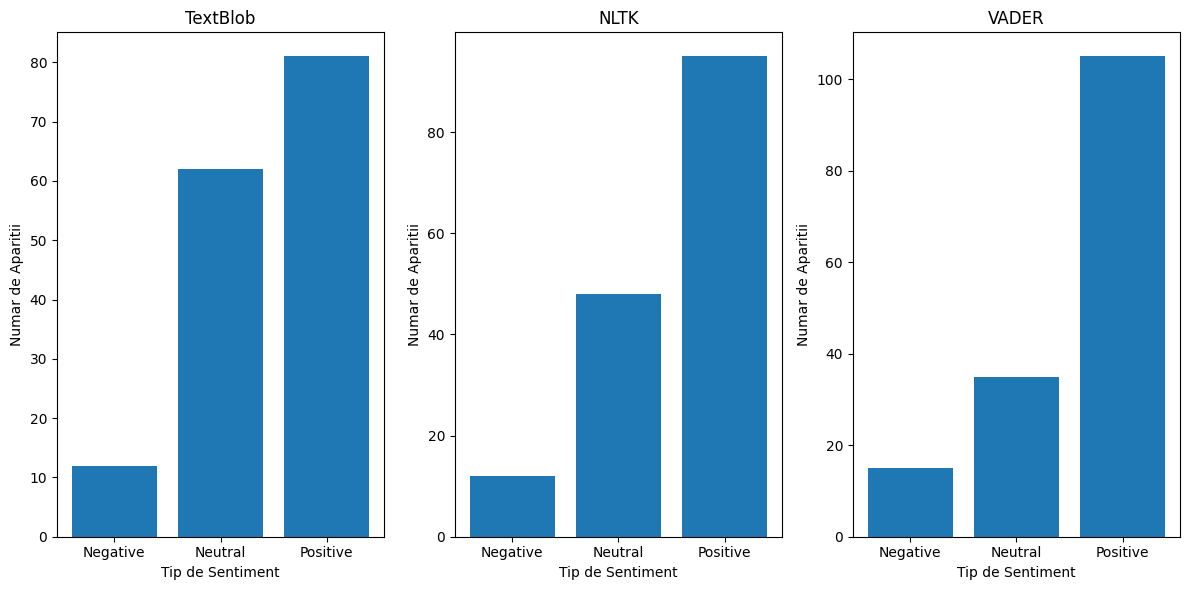

Comentariile au fost updatate in fisier  NLP_video2_sentiment.csv


In [0]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as VaderSentimentIntensityAnalyzer

def determina_tip_sentiment(polaritate):
    if polaritate > 0:
        return 'Positive'
    elif polaritate < 0:
        return 'Negative'
    else:
        return 'Neutral'

def calculeaza_sentiment(nume_fisier_csv, nume_fisier_output_csv):
    data = pd.read_csv(nume_fisier_csv)
    coloana_text = data.columns[0]

    # TextBlob
    data['Sentiment_TextBlob'] = data[coloana_text].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    data['Tip_Sentiment_TextBlob'] = data['Sentiment_TextBlob'].apply(determina_tip_sentiment)

    # NLTK
    import nltk
    nltk.download('vader_lexicon')
    sia = SentimentIntensityAnalyzer()
    data['Sentiment_NLTK'] = data[coloana_text].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    data['Tip_Sentiment_NLTK'] = data['Sentiment_NLTK'].apply(determina_tip_sentiment)

    # VADER
    vader_sia = VaderSentimentIntensityAnalyzer()
    data['Sentiment_VADER'] = data[coloana_text].apply(lambda x: vader_sia.polarity_scores(str(x))['compound'])
    data['Tip_Sentiment_VADER'] = data['Sentiment_VADER'].apply(determina_tip_sentiment)

    # Totalizează numărul de apariții pentru fiecare categorie și metodă
    total_sentiment_textblob = data.groupby('Tip_Sentiment_TextBlob').size().reset_index(name='Total_TextBlob')
    total_sentiment_nltk = data.groupby('Tip_Sentiment_NLTK').size().reset_index(name='Total_NLTK')
    total_sentiment_vader = data.groupby('Tip_Sentiment_VADER').size().reset_index(name='Total_VADER')

    # Afișează totalurile în consolă
    print("Totaluri de sentiment TextBlob:")
    print(total_sentiment_textblob)
    print("\nTotaluri de sentiment NLTK:")
    print(total_sentiment_nltk)
    print("\nTotaluri de sentiment VADER:")
    print(total_sentiment_vader)

    # Salvează rezultatele în fișierul de ieșire
    total_sentiment_textblob.to_csv(nume_fisier_output_csv, index=False)

    # Reprezentare grafică
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.bar(total_sentiment_textblob['Tip_Sentiment_TextBlob'], total_sentiment_textblob['Total_TextBlob'])
    plt.title('TextBlob')
    plt.xlabel('Tip de Sentiment')
    plt.ylabel('Numar de Aparitii')

    plt.subplot(1, 3, 2)
    plt.bar(total_sentiment_nltk['Tip_Sentiment_NLTK'], total_sentiment_nltk['Total_NLTK'])
    plt.title('NLTK')
    plt.xlabel('Tip de Sentiment')
    plt.ylabel('Numar de Aparitii')

    plt.subplot(1, 3, 3)
    plt.bar(total_sentiment_vader['Tip_Sentiment_VADER'], total_sentiment_vader['Total_VADER'])
    plt.title('VADER')
    plt.xlabel('Tip de Sentiment')
    plt.ylabel('Numar de Aparitii')

    plt.tight_layout()
    plt.show()

nume_fisier_csv = 'video_1_NLP.csv'
nume_fisier_output_csv = 'NLP_video2_sentiment.csv'
calculeaza_sentiment(nume_fisier_csv, nume_fisier_output_csv)
print("Comentariile au fost updatate in fisier ", nume_fisier_output_csv)

In [0]:
import re
import pandas as pd
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as VaderSentimentIntensityAnalyzer
from transformers import pipeline
import nltk

# Descărcarea resurselor NLTK necesare
nltk.download('punkt')
print("Resursa 'punkt' a fost descărcată cu succes.")
nltk.download('vader_lexicon')
print("Resursa 'vader_lexicon' a fost descărcată cu succes.")

# Inițializarea pipeline-ului de analiză a sentimentului cu un model specific
sentiment_pipeline = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')
#https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english
# Funcție pentru curățarea textului
def curata_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Elimină caracterele speciale și cifrele
    text = text.lower()  # Transformă textul în litere mici
    text = text.strip()  # Elimină spațiile de la început și sfârșit
    return text

# Funcție pentru a calcula sentimentul folosind Hugging Face Transformers
def sentiment_huggingface(text):
    result = sentiment_pipeline(text)[0]
    return result['label'], result['score']

def calculeaza_sentiment(nume_fisier_csv, nume_fisier_output_csv):
    # Citește datele din fișierul CSV
    data = pd.read_csv(nume_fisier_csv)
    coloana_text = data.columns[0]

    # Curăță textul și adaugă o coloană nouă
    data['Text_Curat'] = data[coloana_text].apply(curata_text)

    # TextBlob
    data['Sentiment_TextBlob'] = data['Text_Curat'].apply(lambda x: TextBlob(x).sentiment.polarity)

    # NLTK
    sia = SentimentIntensityAnalyzer()
    data['Sentiment_NLTK'] = data['Text_Curat'].apply(lambda x: sia.polarity_scores(x)['compound'])

    # VADER
    vader_sia = VaderSentimentIntensityAnalyzer()
    data['Sentiment_VADER'] = data['Text_Curat'].apply(lambda x: vader_sia.polarity_scores(x)['compound'])

    # Hugging Face Transformers
    data['Sentiment_HF_Label'], data['Sentiment_HF_Score'] = zip(*data['Text_Curat'].apply(lambda x: sentiment_huggingface(x)))

    # Salvează rezultatele într-un fișier CSV de ieșire
    data.to_csv(nume_fisier_output_csv, index=False)
    print(f"Comentariile au fost actualizate în fișierul {nume_fisier_output_csv}")

# Specificați calea către fișierul CSV de intrare și de ieșire
nume_fisier_csv = 'video_1_NLP.csv'
nume_fisier_output_csv = 'NLP_video2_sentiment_extins.csv'
calculeaza_sentiment(nume_fisier_csv, nume_fisier_output_csv)


Resursa 'punkt' a fost descărcată cu succes.
Resursa 'vader_lexicon' a fost descărcată cu succes.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Comentariile au fost actualizate în fișierul NLP_video2_sentiment_extins.csv


In [0]:
%pip install pandas torch transformers

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# ... librăriile necesare
import pandas as pd
from transformers import pipeline
import warnings

# Dezactivează avertismentele viitoare inutile
warnings.filterwarnings("ignore", category=FutureWarning)

# Funcția principală pentru analiza sentimentului
def calculeaza_sentiment_huggingface(nume_fisier_csv, nume_fisier_output_csv):
    # Citește datele din fișierul CSV
    data = pd.read_csv(nume_fisier_csv)
    coloana_text = data.columns[0]   # presupunem că textul este în prima coloană

    # Creează un pipeline de analiză a sentimentului
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
        revision="af0f99b"
    )

    # Aplică analiza sentimentului pe fiecare text
    rezultate = data[coloana_text].apply(lambda x: sentiment_pipeline(str(x))[0])

    # Extrage labelul și scorul într-un DataFrame nou
    data["Sentiment_Label"] = rezultate.apply(lambda r: r["label"])
    data["Sentiment_Score"] = rezultate.apply(lambda r: r["score"])

    # Salvează rezultatul într-un fișier CSV nou
    data.to_csv(nume_fisier_output_csv, index=False)
    print(f"Analiza sentimentelor a fost salvată în: {nume_fisier_output_csv}")

# Exemplu de utilizare:
nume_fisier_csv = "video_1_NLP.csv"
nume_fisier_output_csv = "NLP_video2_sentiment_huggingface.csv"

calculeaza_sentiment_huggingface(nume_fisier_csv, nume_fisier_output_csv)


pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Analiza sentimentelor a fost salvată în: NLP_video2_sentiment_huggingface.csv
